In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [28]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [30]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [31]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [32]:
print(f"U podacima se nalazi: {df.duplicated().sum()} duplikata")

U podacima se nalazi: 240 duplikata


In [33]:
df.drop_duplicates(inplace=True)

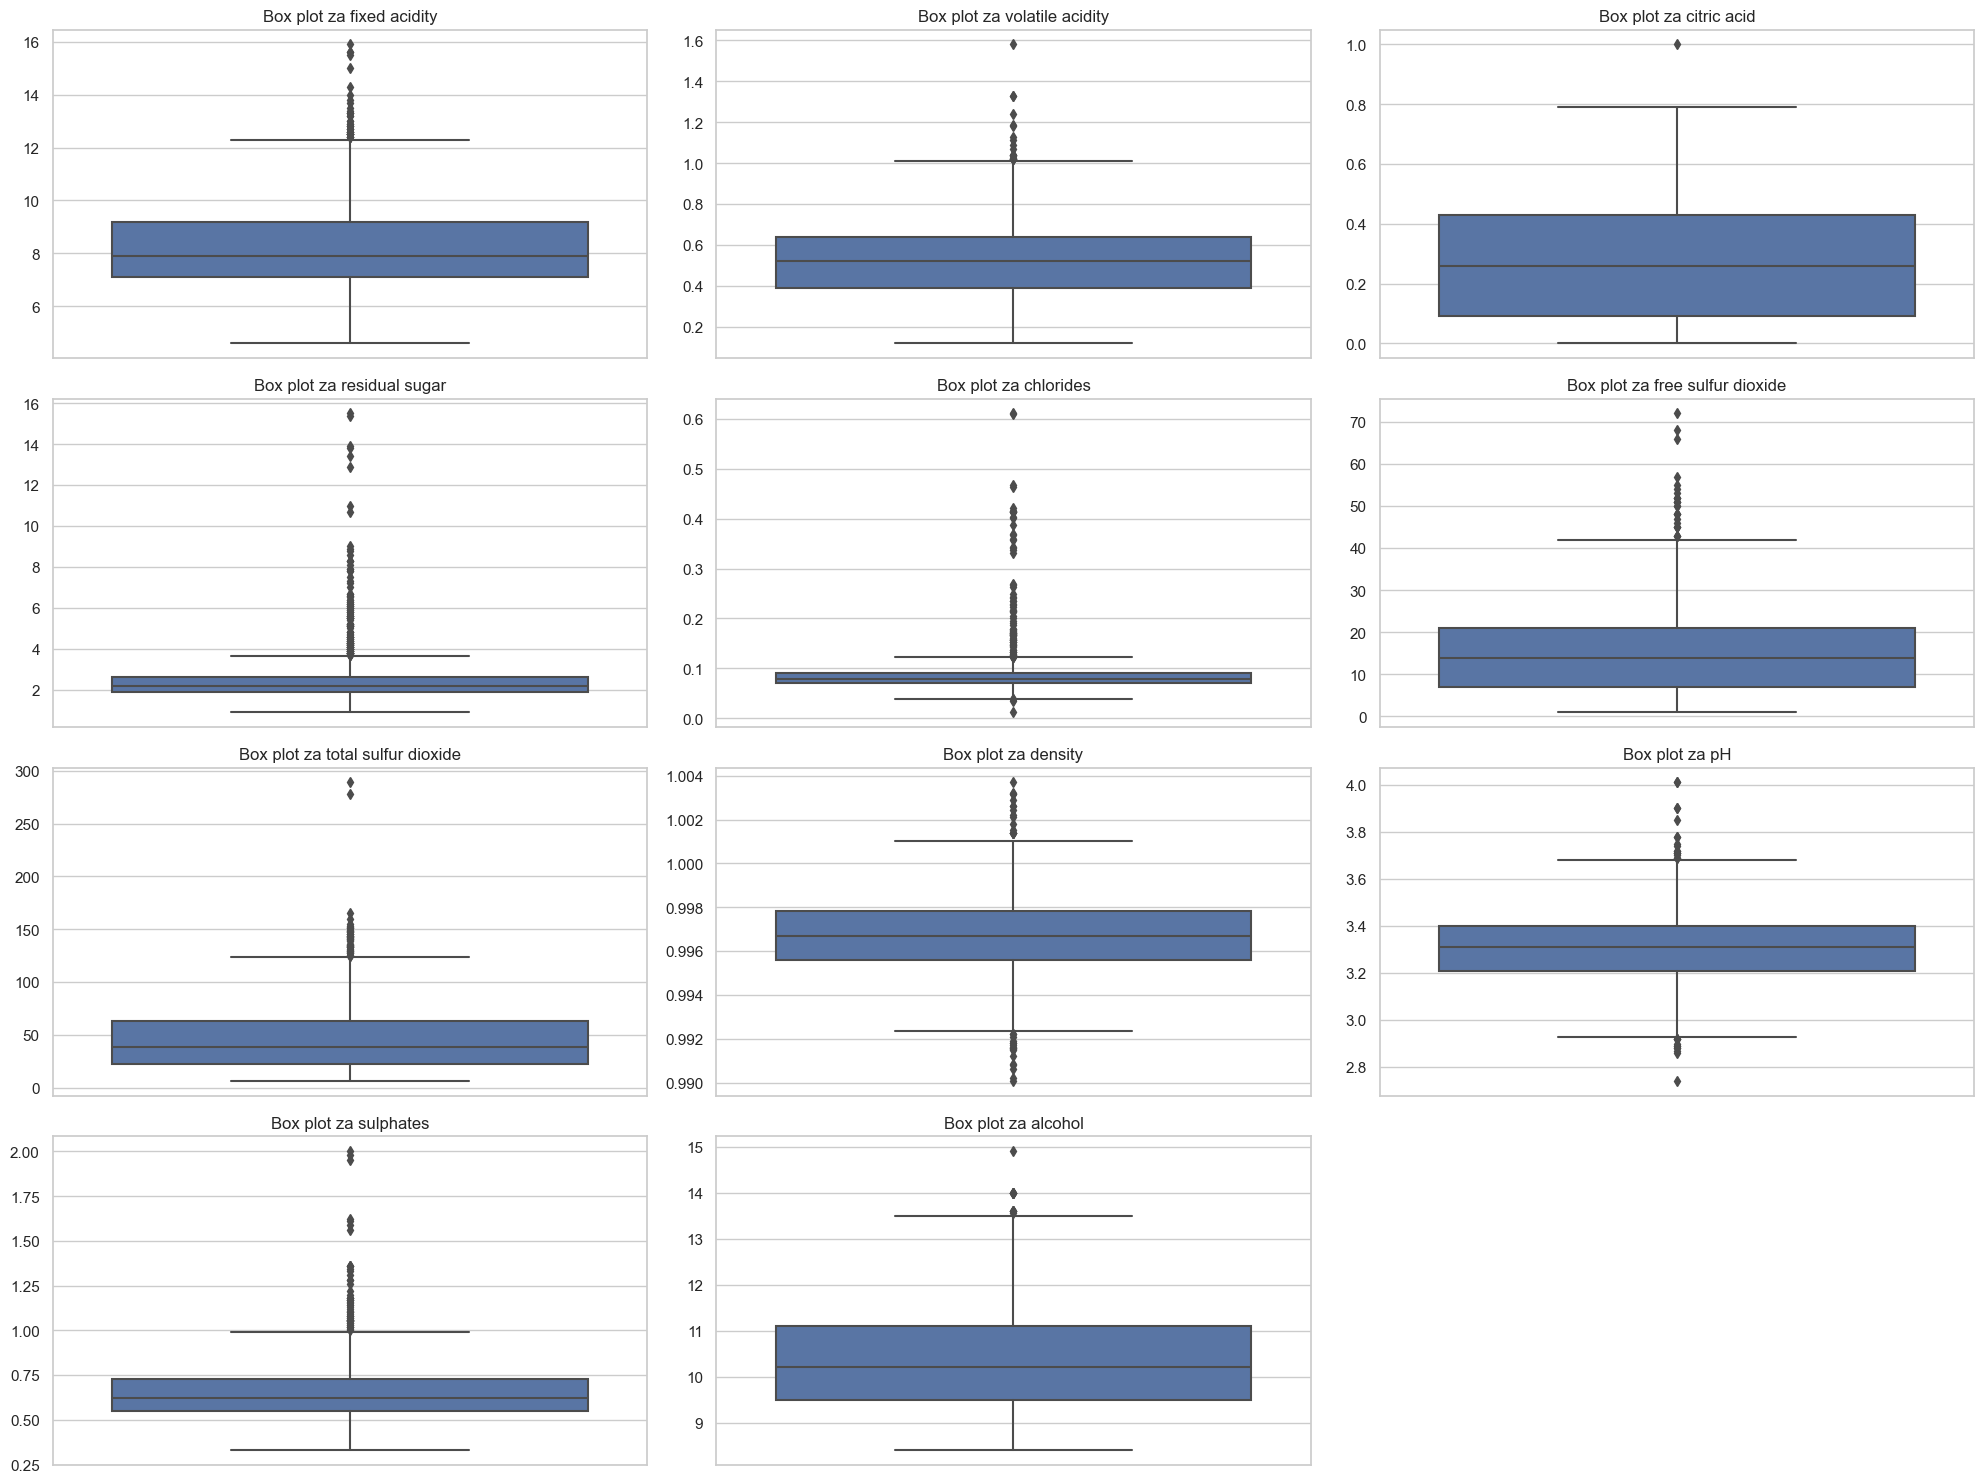

In [34]:
kolone_za_proveru = df.columns.drop('quality')

plt.figure(figsize=(20, 15))
for i, col in enumerate(kolone_za_proveru, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot za {col}')
    plt.ylabel('')
plt.tight_layout()
plt.savefig("boxplot.jpg")

In [35]:
df_bez_outliera = df.copy()
print(f"Početni broj redova: {len(df_bez_outliera)}")
for col in kolone_za_proveru:
    Q1 = df_bez_outliera[col].quantile(0.25)
    Q3 = df_bez_outliera[col].quantile(0.75)
    IQR = Q3 - Q1
    
    donja_granica = Q1 - 1.5 * IQR
    gornja_granica = Q3 + 1.5 * IQR
    
    broj_outliera = df_bez_outliera[(df_bez_outliera[col] < donja_granica) | (df_bez_outliera[col] > gornja_granica)].shape[0]   
    if broj_outliera > 0:
        print(f"U koloni '{col}' pronađeno {broj_outliera} outliera.")      
    df_bez_outliera = df_bez_outliera[(df_bez_outliera[col] >= donja_granica) & (df_bez_outliera[col] <= gornja_granica)]

print(f"\nKonačan broj redova nakon uklanjanja outliera: {len(df_bez_outliera)}")
print(f"Ukupno uklonjeno redova: {len(df) - len(df_bez_outliera)}")

Početni broj redova: 1359
U koloni 'fixed acidity' pronađeno 41 outliera.
U koloni 'volatile acidity' pronađeno 19 outliera.
U koloni 'citric acid' pronađeno 1 outliera.
U koloni 'residual sugar' pronađeno 112 outliera.
U koloni 'chlorides' pronađeno 73 outliera.
U koloni 'free sulfur dioxide' pronađeno 23 outliera.
U koloni 'total sulfur dioxide' pronađeno 44 outliera.
U koloni 'density' pronađeno 20 outliera.
U koloni 'pH' pronađeno 16 outliera.
U koloni 'sulphates' pronađeno 23 outliera.
U koloni 'alcohol' pronađeno 2 outliera.

Konačan broj redova nakon uklanjanja outliera: 985
Ukupno uklonjeno redova: 374


Distribucija ocena kvaliteta bez outliera:
quality
3      2
4     32
5    415
6    411
7    116
8      9
Name: count, dtype: int64


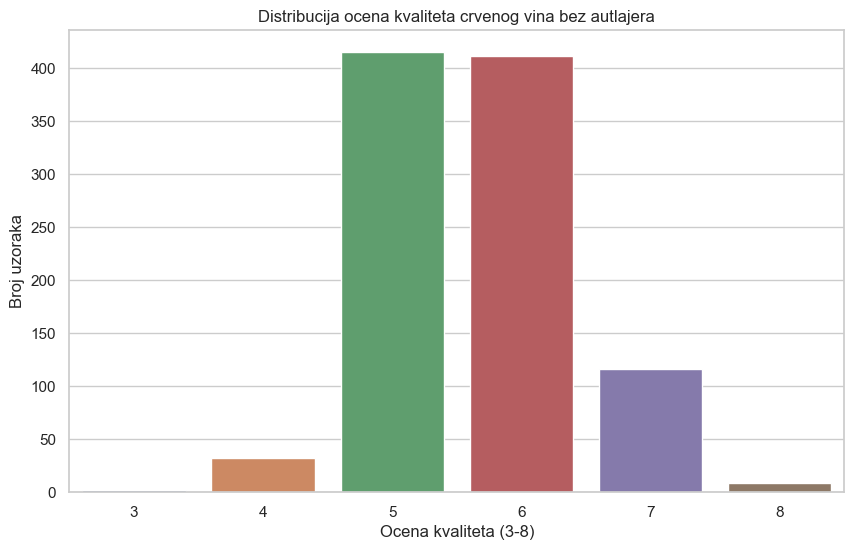

In [36]:
print("Distribucija ocena kvaliteta bez outliera:")
print(df_bez_outliera['quality'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=df_bez_outliera)
plt.title('Distribucija ocena kvaliteta crvenog vina bez autlajera')
plt.xlabel('Ocena kvaliteta (3-8)')
plt.ylabel('Broj uzoraka')
plt.savefig("outlierdist.jpg")

Distribucija originalnih ocena kvaliteta:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


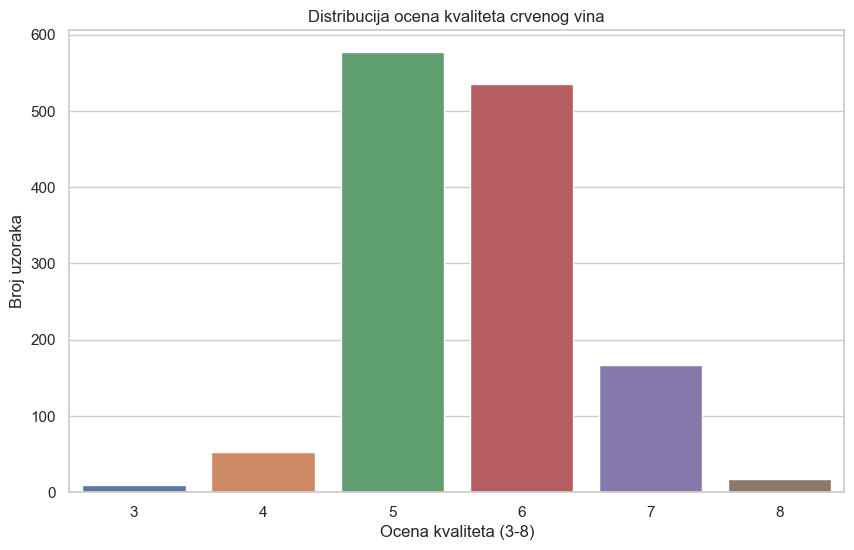

In [37]:
print("Distribucija originalnih ocena kvaliteta:")
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=df)
plt.title('Distribucija ocena kvaliteta crvenog vina')
plt.xlabel('Ocena kvaliteta (3-8)')
plt.ylabel('Broj uzoraka')
plt.savefig("distqu.jpg")

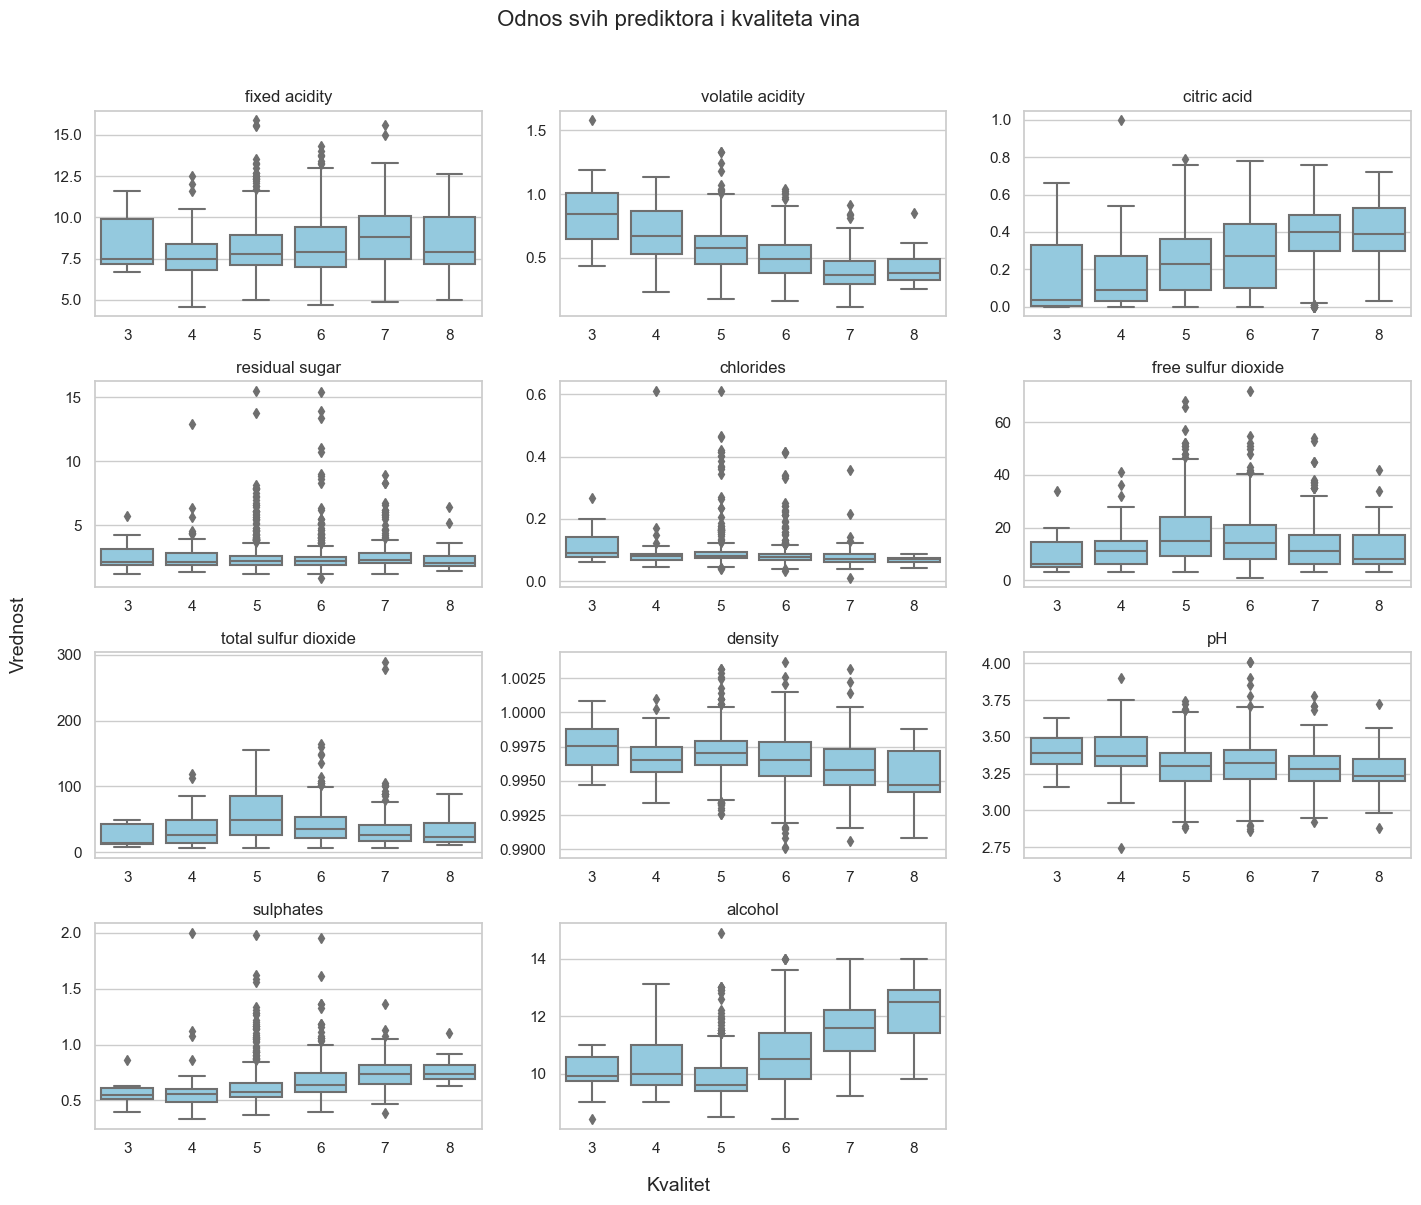

<Figure size 640x480 with 0 Axes>

In [38]:
prediktori = df.columns.drop('quality')

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))

for i, col_name in enumerate(prediktori):
    ax = axes.flatten()[i]  

    sns.boxplot(
        x='quality',        
        y=col_name,         
        data=df,            
        ax=ax,              
        color='skyblue'    
    )
    ax.set_title(col_name.replace('.', ' '))
    ax.set_xlabel('')
    ax.set_ylabel('') 
axes.flatten()[-1].set_visible(False)

fig.suptitle('Odnos svih prediktora i kvaliteta vina', fontsize=16, y=1.02)
fig.text(0.5, 0.04, 'Kvalitet', ha='center', va='center', fontsize=14)
fig.text(0.06, 0.5, 'Vrednost', ha='center', va='center', rotation='vertical', fontsize=14)
plt.tight_layout(rect=[0.07, 0.05, 1, 1])


plt.show()
plt.savefig("boxplotov.png")

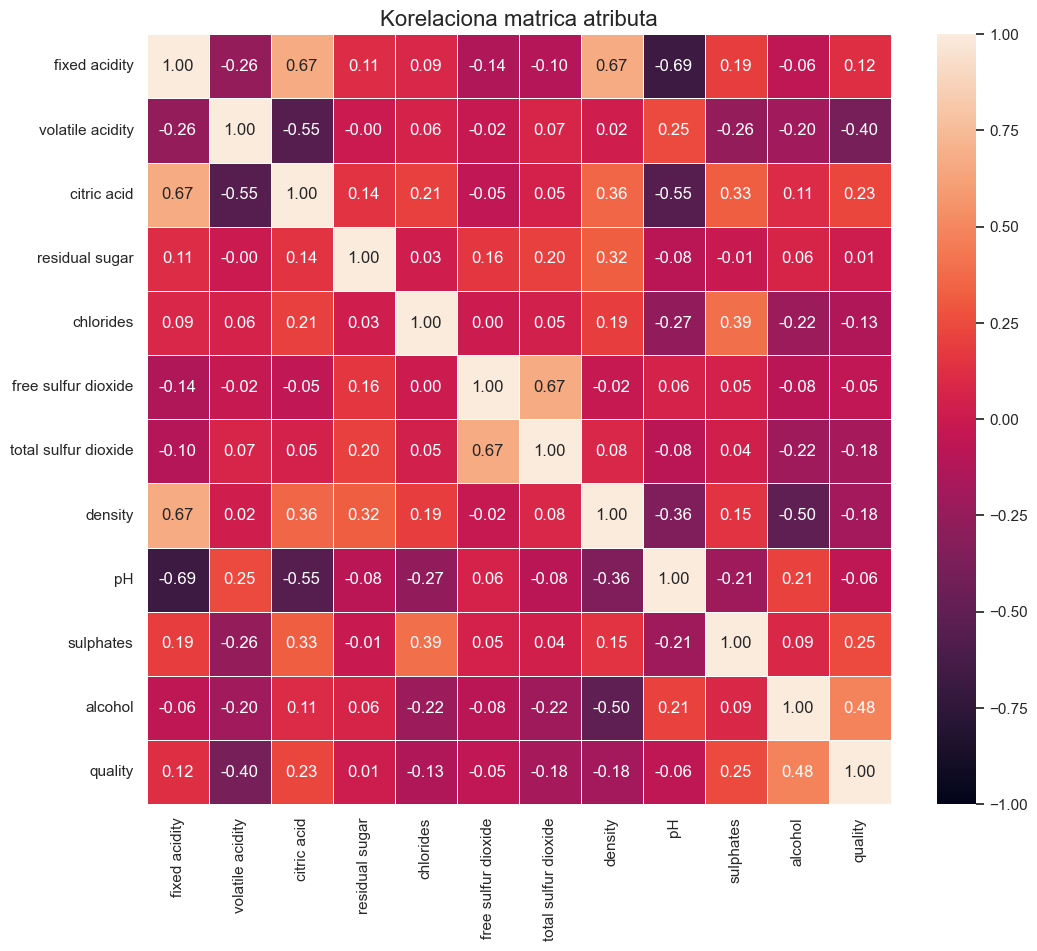

<Figure size 640x480 with 0 Axes>

In [39]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))

# Generisanje mape
sns.heatmap(
    corr_matrix, 
    annot=True,      
    fmt='.2f',       
    linewidths=.5,   
    vmin=-1,         
    vmax=1          
)

plt.title('Korelaciona matrica atributa', fontsize=16)

plt.show()
plt.savefig("korelaciona.jpg")

In [40]:
bins = [0, 4, 6, 10] 
labels = ['loše', 'prosečno', 'dobro']
df['quality_category'] = pd.cut(df['quality'], bins=bins, labels=labels, right=True)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,prosečno
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,prosečno
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,prosečno
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,prosečno
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,prosečno


Distribucija novih kategorija kvaliteta:
quality_category
prosečno    1112
dobro        184
loše          63
Name: count, dtype: int64


Text(0, 0.5, 'Broj uzoraka')

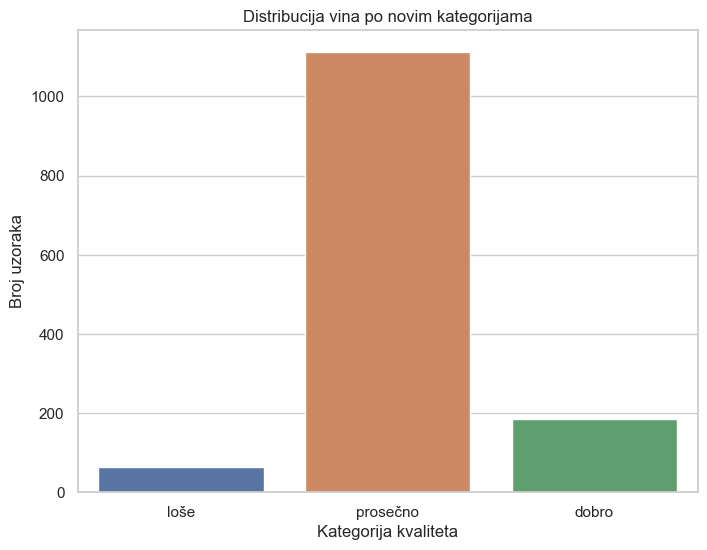

In [41]:
print("Distribucija novih kategorija kvaliteta:")
print(df['quality_category'].value_counts())


plt.figure(figsize=(8, 6))
sns.countplot(x='quality_category', data=df, order=['loše', 'prosečno', 'dobro'])
plt.title('Distribucija vina po novim kategorijama')
plt.xlabel('Kategorija kvaliteta')
plt.ylabel('Broj uzoraka')

In [16]:
X = df.drop(['quality', 'quality_category'], axis=1)
y_text = df['quality_category']

In [44]:
mapa= {'loše': 0,'prosečno': 1,'dobro': 2}
df['quality_encoded'] = df['quality_category'].map(mapa)
y_encoded= df['quality_encoded']
y_encoded.value_counts()

quality_encoded
1    1112
2     184
0      63
Name: count, dtype: int64

In [45]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_category,quality_encoded
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,prosečno,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,prosečno,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,prosečno,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,prosečno,1
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,prosečno,1


In [46]:
X = df.drop(['quality', 'quality_category','quality_encoded'], axis=1)
Y=y_encoded

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print("\n--- Veličina skupova ---")
print(f"Veličina X_train: {X_train.shape}")
print(f"Veličina X_test: {X_test.shape}")
print(f"Veličina y_train: {y_train.shape}")
print(f"Veličina y_test: {y_test.shape}")


--- Veličina skupova ---
Veličina X_train: (1087, 11)
Veličina X_test: (272, 11)
Veličina y_train: (1087,)
Veličina y_test: (272,)


In [21]:
train_counts = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_counts = pd.Series(y_test).value_counts(normalize=True).sort_index()

print("Distribucija klasa u trening setu:\n", train_counts*100)
print("\nDistribucija klasa u test setu:\n", test_counts*100)

Distribucija klasa u trening setu:
 quality_encoded
0     4.599816
1    81.876725
2    13.523459
Name: proportion, dtype: float64

Distribucija klasa u test setu:
 quality_encoded
0     4.779412
1    81.617647
2    13.602941
Name: proportion, dtype: float64


In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Veličina pre SMOTE-a:")
print("X_train:", X_train.shape)
print("y_train:", pd.Series(y_train).value_counts())

Veličina pre SMOTE-a:
X_train: (1087, 11)
y_train: quality_encoded
1    890
2    147
0     50
Name: count, dtype: int64


In [63]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print("Veličina posle SMOTE-a:")
print("X_train:", X_train_resampled.shape)
print("\nDistribucija klasa NAKON SMOTE-a:")
print(pd.Series(y_train_resampled).value_counts())

Veličina posle SMOTE-a:
X_train: (2670, 11)

Distribucija klasa NAKON SMOTE-a:
quality_encoded
0    890
1    890
2    890
Name: count, dtype: int64


--- 1. Rezultati stabla odlučivanja pre SMOTE---

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.25      0.15      0.19        13
           1       0.88      0.83      0.85       222
           2       0.40      0.59      0.48        37

    accuracy                           0.76       272
   macro avg       0.51      0.53      0.51       272
weighted avg       0.78      0.76      0.77       272

Matrica konfuzije:


Text(0.5, 1.0, 'Matrica konfuzije - Stablo odlučivanja pre SMOTE (max_depth=13)')

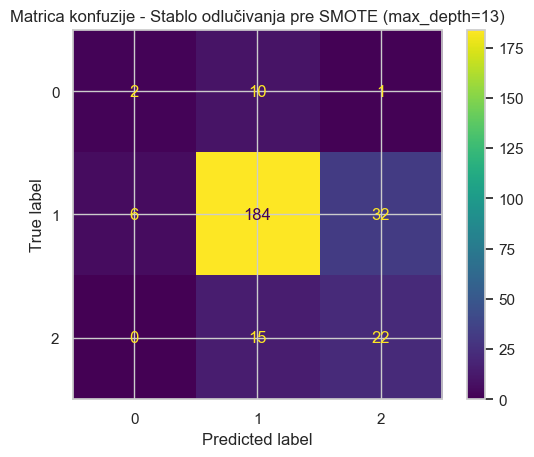

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

dt_model = DecisionTreeClassifier(max_depth=13, class_weight='balanced', random_state=42,criterion='gini')

dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("--- 1. Rezultati stabla odlučivanja pre SMOTE---")

print("\nIzveštaj o klasifikaciji:")
print(classification_report(y_test, y_pred_dt))

print("Matrica konfuzije:")
ConfusionMatrixDisplay.from_estimator(dt_model, X_test_scaled, y_test)
plt.title('Matrica konfuzije - Stablo odlučivanja pre SMOTE (max_depth=13)')

--- 1. Rezultati stabla odlučivanja posle SMOTE---

Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.18      0.54      0.27        13
           1       0.89      0.71      0.79       222
           2       0.43      0.65      0.52        37

    accuracy                           0.69       272
   macro avg       0.50      0.63      0.53       272
weighted avg       0.80      0.69      0.73       272

Matrica konfuzije:


Text(0.5, 1.0, 'Matrica konfuzije - Stablo Odlučivanja posle SMOTE (max_depth=15)')

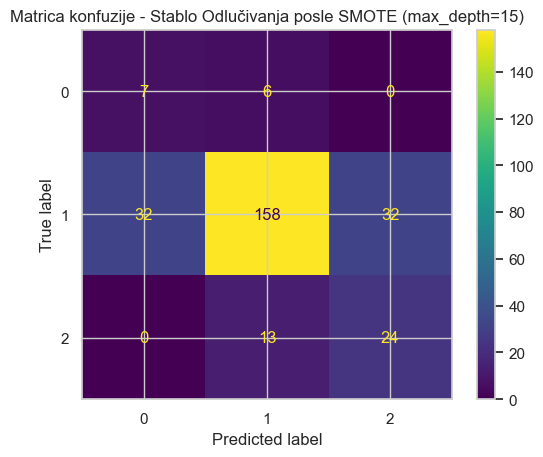

In [90]:
dt_model_smote = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model_smote.fit(X_train_resampled, y_train_resampled)
y_pred_dt_smote = dt_model_smote.predict(X_test_scaled)
print("--- 1. Rezultati stabla odlučivanja posle SMOTE---")
print("\nIzveštaj o klasifikaciji:")
print(classification_report(y_test, y_pred_dt_smote))

print("Matrica konfuzije:")
ConfusionMatrixDisplay.from_estimator(dt_model_smote, X_test_scaled, y_test)
plt.title('Matrica konfuzije - Stablo Odlučivanja posle SMOTE (max_depth=15)')

--- 2. Random Forest pre SMOTE---
Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       1.00      0.08      0.14        13
           1       0.87      0.93      0.90       222
           2       0.55      0.49      0.51        37

    accuracy                           0.83       272
   macro avg       0.81      0.50      0.52       272
weighted avg       0.83      0.83      0.81       272

Matrica konfuzije:


Text(0.5, 1.0, 'Matrica konfuzije - Random Forest (max_depth=10)')

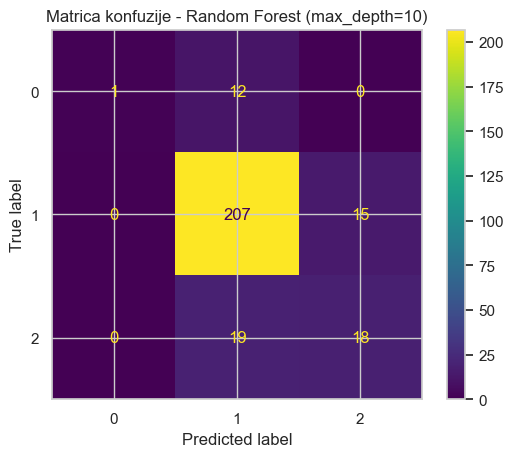

In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced',criterion='gini',bootstrap=True,max_depth=10)

rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)

print("--- 2. Random Forest pre SMOTE---")
print("Izveštaj o klasifikaciji:")
print(classification_report(y_test, y_pred))

print("Matrica konfuzije:")
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title('Matrica konfuzije - Random Forest (max_depth=10)')

--- 2. Random Forest posle SMOTE---
Izveštaj o klasifikaciji:
              precision    recall  f1-score   support

           0       0.33      0.38      0.36        13
           1       0.91      0.84      0.87       222
           2       0.50      0.70      0.58        37

    accuracy                           0.80       272
   macro avg       0.58      0.64      0.60       272
weighted avg       0.82      0.80      0.81       272

Matrica konfuzije:


Text(0.5, 1.0, 'Matrica konfuzije - Random Forest posle SMOTE (max_depth=11)')

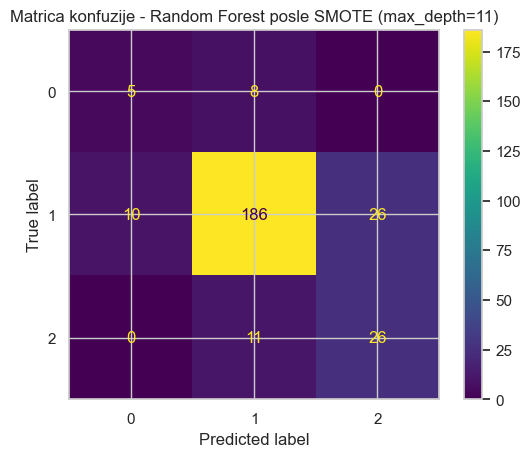

In [93]:
rf_model_smote = RandomForestClassifier(random_state=42,max_depth=11)

rf_model_smote.fit(X_train_resampled, y_train_resampled)

y_pred_smote = rf_model_smote.predict(X_test_scaled)
print("--- 2. Random Forest posle SMOTE---")
print("Izveštaj o klasifikaciji:")
print(classification_report(y_test, y_pred_smote))

print("Matrica konfuzije:")
ConfusionMatrixDisplay.from_estimator(rf_model_smote, X_test_scaled, y_test)
plt.title('Matrica konfuzije - Random Forest posle SMOTE (max_depth=11)')

In [95]:
los_primer_vina = pd.DataFrame({
    'fixed acidity': [7.8],
    'volatile acidity': [0.95],  # Visoka vrednost, tipično za loša vina
    'citric acid': [0.05],       # Niska vrednost
    'residual sugar': [2.8],
    'chlorides': [0.08],
    'free sulfur dioxide': [10.0],
    'total sulfur dioxide': [40.0],
    'density': [0.9970],
    'pH': [3.35],
    'sulphates': [0.55],
    'alcohol': [9.4]             # Niska vrednost
})
primer_vina_scaled = scaler.transform(los_primer_vina)
rf_predikcija=dt_model.predict(primer_vina_scaled)
rf_verovatnoce = dt_model.predict_proba(primer_vina_scaled)
rf_predikcija, rf_verovatnoce 

(array([0], dtype=int64), array([[1., 0., 0.]]))

In [96]:
dt_predikcija=dt_model_smote.predict(primer_vina_scaled)
dt_verovatnoce=dt_model_smote.predict
dt_predikcija #predvideo tacno

array([0], dtype=int64)

In [97]:
rf_predikcija=rf_model_smote.predict(primer_vina_scaled)
rf_verovatnoce=rf_model_smote.predict
rf_predikcija #predvideo tacno

array([0], dtype=int64)

In [98]:
rf_predikcija=rf_model.predict(primer_vina_scaled)
rf_verovatnoce=rf_model.predict
rf_predikcija #predvideo tacno

array([1], dtype=int64)